# Solid Effect
## Author: Vineeth Francis Thalakottoor, vineeth.thalakottoor@ens.psl.eu or vineethfrancis.physics@gmail.com
- Nuclear Orientation via Electron Spin Locking
- In Hilbert Space
- Redfield Master equation
- Thanks to Pulsed DNP Workshop at Lyon 2026 (Sami Jannin and team) 
- Ref: Essentials of Dynamic Nuclear Polarization, Tom Wenckebach. Equation 6.20 and Figure 6.8

In [1]:
# Define the source path
SourcePath = '/home/vineeth/Documents/PyOR/PyOR/Source_Doc'

# Add source path
import sys
sys.path.append(SourcePath)
import time
%matplotlib ipympl

# Import PyOR package
from PyOR_QuantumSystem import QuantumSystem as QunS
from PyOR_Hamiltonian import Hamiltonian
from PyOR_DensityMatrix import DensityMatrix
from PyOR_QuantumObject import QunObj
from PyOR_HardPulse import HardPulse
from PyOR_Basis import Basis
from PyOR_Evolution import Evolutions
from PyOR_Plotting import Plotting
import PyOR_SignalProcessing as Spro

import numpy as np

In [2]:
# Define the spin system
Spin_list = {"A" : "E", "B" : "H1"}
QS = QunS(Spin_list,PrintDefault=False)
QS.print_Larmor = False
# initialize the system
QS.Initialize()

Spin Operators generated (Quantum Objects)
For particle A: Ax, Ay, Az, Ap, Am
For particle B: Bx, By, Bz, Bp, Bm

To see the matrix form use the attribute .matrix
Spin Operators generated (Quantum Objects)
For particle A: Ax, Ay, Az, Ap, Am
For particle B: Bx, By, Bz, Bp, Bm

To see the matrix form use the attribute .matrix


### Set parameters

In [3]:
# Master Equation
QS.PropagationSpace = "Hilbert"
QS.MasterEquation = "Redfield"

# B0 Field in Tesla, Static Magnetic field (B0) along Z
QS.B0 = 3.4

# Offset Frequency in rotating frame (Hz)
QS.OFFSET["A"] = 0.0
QS.OFFSET["B"] = 0.0

# Relaxation Process
QS.Rprocess = "No Relaxation"

QS.Update()

Spin Operators generated (Quantum Objects)
For particle A: Ax, Ay, Az, Ap, Am
For particle B: Bx, By, Bz, Bp, Bm

To see the matrix form use the attribute .matrix

Setting derived parameters from dictionaries
-------------------------------------------
OmegaRF   <- OMEGA_RF  : [598740000000.0, -909574800.0] from {'A': 598740000000.0, 'B': -909574800.0}
Offset    <- OFFSET    : [0.0, 0.0] from {'A': 0.0, 'B': 0.0}
Ispintemp <- I_spintemp: [300, 300] from {'A': 300, 'B': 300}
Fspintemp <- F_spintemp: [300, 300] from {'A': 300, 'B': 300}
RDxi      <- RD_xi     : [0, 0] from {'A': 0, 'B': 0}
RDphase   <- RD_phase  : [0, 0] from {'A': 0, 'B': 0}
-------------------------------------------


# Solid Effect

In [4]:
nPoints = 100
nMWPoints = 200
Omega_MW_I = QS.OMEGA_RF["A"] - 2.0 * QS.OMEGA_RF["B"] 
Omega_MW_F = QS.OMEGA_RF["A"] + 2.0 * QS.OMEGA_RF["B"] 

Omega_E = QS.OMEGA_RF["A"]       # Electron Larmor
Omega_H = QS.OMEGA_RF["B"]       # Proton Larmor
Omega1_E = 2.0 * np.pi * 1.0e6   # Electron B1
print("Electron Larmor Frequency = ", Omega_E/(2.0*np.pi))
print("Proton Larmor Frequency = ", Omega_H/(2.0*np.pi))
print("2 x Proton Larmor Frequency = ", 2.0 * np.abs(Omega_H)/(2.0*np.pi))
print("Electron Larmor Frequency - Proton Larmor Frequency = ", (Omega_E - Omega_H)/(2.0*np.pi))
print("Electron Larmor Frequency + Proton Larmor Frequency = ", (Omega_E + Omega_H)/(2.0*np.pi))

Intensity = np.zeros((nMWPoints))
Omega_MW =  np.linspace(Omega_MW_I,Omega_MW_F,nMWPoints)
j = 0

start_time = time.time()
for i in Omega_MW:
    Azp = 2.0 * 3.14 * 1.0e6     # Coupling
    Azm = 2.0 * 3.14 * 1.0e6     # Coupling

    SinT = Omega1_E / np.sqrt((Omega_E - i)**2 + (Omega1_E)**2)
    CosT = (Omega_E - i) / np.sqrt((Omega_E - i)**2 + (Omega1_E)**2)
    
    H = (
        (Omega_E - i) * QS.Az + 0.5 * Omega1_E * (QS.Ap + QS.Am) - Omega_H * QS.Bz
        - (1.0 / 8.0) * (QS.Ap + QS.Am) * (Azp * QS.Bp - Azm * QS.Bm) * SinT * CosT
        - (1.0 / 8.0) * (QS.Ap - QS.Am) * (Azp * QS.Bp - Azm * QS.Bm) * SinT
    ) # Total Hamiltonian, Essentials of Dynamic Nuclear Polarization, Tom Wenckebach, Eq: 6.20

    rho_in = QS.Az             # Initial Density Matrix
    rhoeq = QS.Az

    # Pulse
    #HardP = HardPulse(QS)
    #flip_angle1 = 90.0   # Flip angle Spin 1
    rho = rho_in #HardP.Rotate_Pulse(rho_in,flip_angle1,QS.Ay)

    # Evolution
    Contact_time = 2e-6
    QS.AcqDT =  Contact_time / nPoints
    QS.AcqAQ = Contact_time

    QS.PropagationMethod = "Unitary Propagator"

    Ham = Hamiltonian(QS)
    EVol = Evolutions(QS,Ham)

    t, rho_t = EVol.Evolution(rho,rhoeq,H)

    # Expectation
    det_X1 = QS.Ax
    det_Z2 = QS.Bz

    t, signal_X1 = EVol.Expectation(rho_t,det_X1)
    t, signal_Z2 = EVol.Expectation(rho_t,det_Z2)
    Intensity[j] = np.sum(signal_Z2.real)

    j = j + 1
    end_time = time.time()
    timetaken = end_time - start_time
print("Total time = %s seconds " % (timetaken))

Electron Larmor Frequency =  95292430626.84142
Proton Larmor Frequency =  -144763325.5318221
2 x Proton Larmor Frequency =  289526651.0636442
Electron Larmor Frequency - Proton Larmor Frequency =  95437193952.37325
Electron Larmor Frequency + Proton Larmor Frequency =  95147667301.3096
Total time = 2.767407178878784 seconds 


## Plotting

In [5]:
plot = Plotting(QS)

(<Figure size 1000x500 with 1 Axes>,
 <matplotlib.widgets.SpanSelector at 0x7b852f7f5220>)

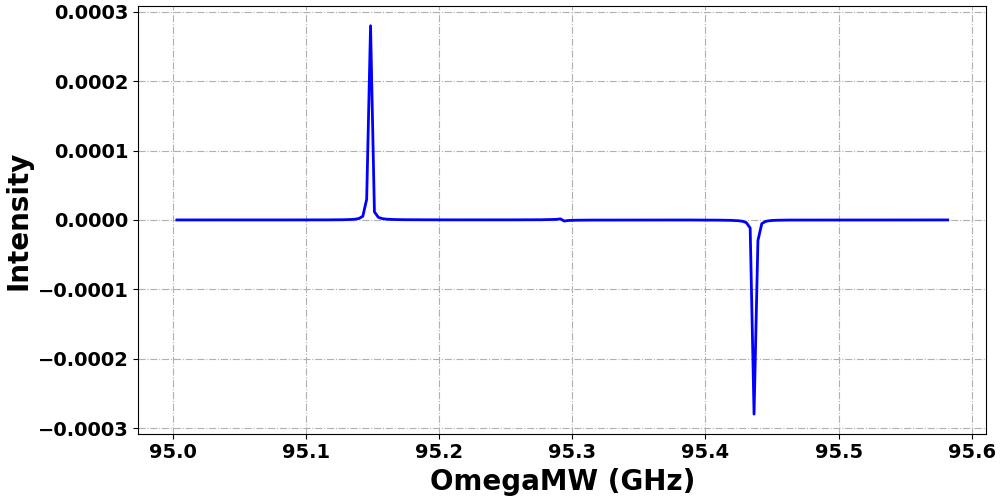

In [6]:
plot.PlotFigureSize = (10,5)
plot.PlotFontSize = 20
plot.Plotting_SpanSelector(Omega_MW * 1.0e-9 /(2.0*np.pi),Intensity,"OmegaMW (GHz)","Intensity","blue")